## Main Objectives
We have worked on:
data preprocessing, EDA, filling the missing data of categorical features energy and heating with semi-supervised learning models, data cleaning includes outliers detection and handling using log,  Yeo-Johnson and z-score Transformations instead of dropping them easily, dimensionality reduction via meta data recognition and correlation coefficient and as final objective: predicting property prices with supervised machine learning models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

In [2]:
data = pd.read_csv("real_estate.csv")

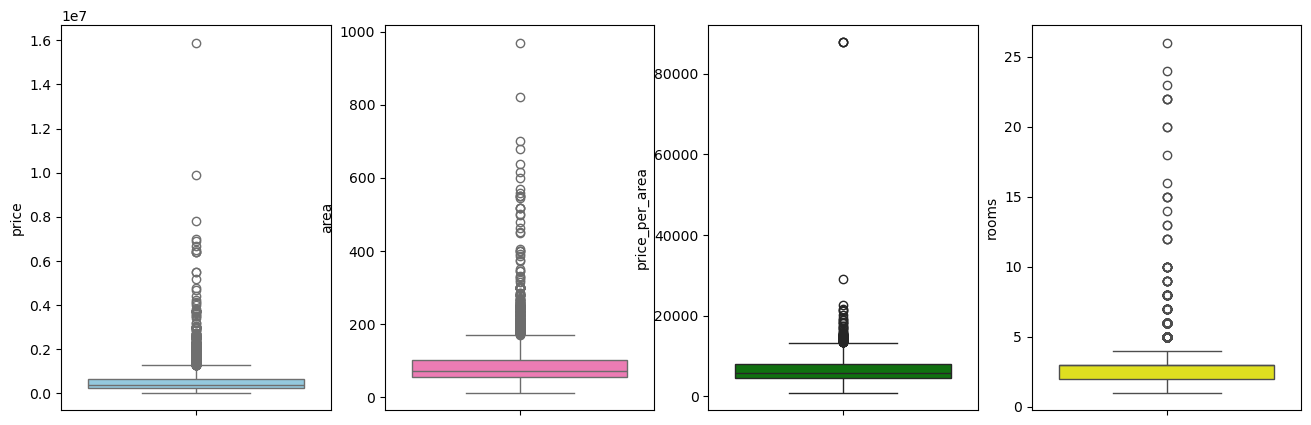

In [3]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(data['price'],color='skyblue')
plt.subplot(142)
sns.boxplot(data['area'],color='hotpink')
plt.subplot(143)
sns.boxplot(data['price_per_area'],color='green')
plt.subplot(144)
sns.boxplot(data['rooms'],color='yellow')
plt.show()

In [4]:
# # Data cleaning - removing outliers based on IQR (fixed)
# # really low accuracy(≈60%)
# cols = ['price', 'area', 'rooms', 'price_per_area']

# mask = pd.Series(True, index=data.index)
# for col in cols:
#     Q1 = data[col].quantile(0.25)
#     Q3 = data[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     col_mask = (data[col] >= lower) & (data[col] <= upper)
#     print(f"{col}: bounds [{lower:.2f}, {upper:.2f}] | removed {(~col_mask).sum()}")
#     mask &= col_mask

# data_cleaned = data[mask].copy().reset_index(drop=True)

# print(f"\nOriginal rows: {len(data)}")
# print(f"Removed: {(~mask).sum()}")
# print(f"Remaining: {len(data_cleaned)}")
# print(data_cleaned[cols].describe())

## Log Transformation

In [53]:
# Log Transformation to reduce the effect of outliers
# No rows are removed
# Better accuracy(78.5%)

log_columns = ['price', 'area', 'price_per_area', 'rooms']

data_cleaned = data.copy()

for col in log_columns:
    data_cleaned[col] = np.log1p(data_cleaned[col])

## Winsorize

In [54]:
# # Winsorize
# from scipy.stats.mstats import winsorize
# # accuracy = 75.2%
# data_cleaned = data.copy().reset_index(drop=True)

# for col in ['price', 'area', 'price_per_area', 'rooms']:
#     data_cleaned[col] = winsorize(data_cleaned[col].astype(float), limits=[0.01, 0.01])

# print("Winsorize 1%-99% applied.")
# print("Rows:", len(data_cleaned))
# print(data_cleaned[['price', 'area', 'rooms', 'price_per_area']].describe())

## log + RobustScaler

In [55]:
# # log + RobustScaler
# # better accuracy but more complicated(78.6%)
# from sklearn.preprocessing import RobustScaler

# data_cleaned = data.copy().reset_index(drop=True)

# data_cleaned['price'] = np.log1p(data_cleaned['price'])

# feat_cols = ['area', 'price_per_area', 'rooms']
# rs = RobustScaler()
# data_cleaned[feat_cols] = rs.fit_transform(data_cleaned[feat_cols])

# print("log(price) + RobustScaler on features.")
# print("Rows:", len(data_cleaned))

## Yeo johnson + z-score for the columns price and area

In [56]:
# from scipy import stats
# import numpy as np
# import pandas as pd

# data_cleaned = data.copy().reset_index(drop=True)

# # ----- price: Yeo-Johnson only, then drop remaining IQR outliers -----
# price_yj, lambda_price = stats.yeojohnson(data_cleaned['price'].astype(float).values)
# data_cleaned['price'] = price_yj

# q1_p = np.percentile(price_yj, 25)
# q3_p = np.percentile(price_yj, 75)
# iqr_p = q3_p - q1_p
# low_p = q1_p - 1.5 * iqr_p
# high_p = q3_p + 1.5 * iqr_p
# mask_price_ok = (data_cleaned['price'] >= low_p) & (data_cleaned['price'] <= high_p)

# print(f"price YJ lambda={lambda_price:.6f}")
# print(f"price outliers after YJ (IQR): {(~mask_price_ok).sum()}")

# # ----- area: Yeo-Johnson + z-score, then drop remaining |z|>3 -----
# area_yj, lambda_area = stats.yeojohnson(data_cleaned['area'].astype(float).values)
# area_z = (area_yj - area_yj.mean()) / area_yj.std(ddof=0)
# data_cleaned['area'] = area_z

# mask_area_ok = np.abs(data_cleaned['area']) <= 3

# print(f"area YJ lambda={lambda_area:.6f}")
# print(f"area outliers after YJ+z (|z|>3): {(~mask_area_ok).sum()}")

# # ----- drop rows that are outlier in price or area -----
# # rooms is not used for dropping
# mask_keep = mask_price_ok & mask_area_ok
# removed = int((~mask_keep).sum())

# data_cleaned = data_cleaned.loc[mask_keep].copy().reset_index(drop=True)

# print(f"\nOriginal rows: {len(data)}")
# print(f"Removed rows: {removed}")
# print(f"Remaining rows: {len(data_cleaned)}")
# print(data_cleaned[['price', 'area', 'rooms']].describe())

In [57]:
y = data_cleaned.iloc[:, 3].values
x = data_cleaned.drop('price', axis=1)

In [58]:
x = x.iloc[:, :].values

In [59]:
# define numerical & categorical columns
numeric_features = [feature for feature in data_cleaned.columns if data_cleaned[feature].dtype != 'O']
categorical_features = [feature for feature in data_cleaned.columns if data_cleaned[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 8 numerical features : ['price', 'area', 'rooms', 'fee', 'zipcode', 'construction_year', 'level', 'price_per_area']

We have 3 categorical features : ['url', 'energy', 'heating']


In [60]:
print(data_cleaned['heating'].value_counts())

heating
na                           2112
Zentralheizung               1839
Etagenheizung                 366
Fußbodenheizung,              206
Fußbodenheizung               174
Heizungsart                    70
Kamin,                         34
Wärmepumpe                     30
Wasser-                        24
Kf                             17
Kamin                          15
Niedrigenergiehaus             12
Fußbodenheizung, offener       11
Etagenheizung, offener          8
Etagenheizung,                  6
Heizungsartoffener              4
Luft-/                          3
Wärmepumpe,                     3
Fertighaus                      3
Minergie zertifiziert           2
Ofen,                           1
Wärmepumpe, offener             1
Kohle,                          1
Name: count, dtype: int64


In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.preprocessing import LabelEncoder

In [62]:
# 1. Replace 'na' string representation with actual np.nan
data_cleaned = data_cleaned.copy().reset_index(drop=True)
data_cleaned['heating'] = data_cleaned['heating'].replace('na', np.nan)
data_cleaned['energy'] = data_cleaned['energy'].replace('na', np.nan)

In [63]:
# 2. Define independent numeric features used to predict heating and energy
feature_cols = ['price_per_area', 'rooms', 'level']
X_features = data_cleaned[feature_cols].copy()

In [64]:
# Function to perform Self-Training semi-supervised imputation for a single column
def fill_missing_with_semi_supervised(df_input, target_col, features):
    df_temp = df_input.copy()
    
    # Create mask for labeled (non-missing) rows
    labeled_mask = df_temp[target_col].notna()
    
    # Encode target labels; set unlabeled rows to -1 for SelfTrainingClassifier
    le = LabelEncoder()
    y_encoded = pd.Series(-1, index=df_temp.index)
    y_encoded[labeled_mask] = le.fit_transform(df_temp.loc[labeled_mask, target_col])
    
    # Define base estimator and self-training wrapper
    base_model = RandomForestClassifier(n_estimators=100, random_state=42)
    self_training_model = SelfTrainingClassifier(base_model, threshold=0.75)
    
    # Fit the semi-supervised model on all data
    self_training_model.fit(features, y_encoded)
    
    # Predict pseudo-labels for all samples
    predicted_labels = self_training_model.predict(features)
    
    # Decode numeric labels back to original category names
    df_temp[target_col] = le.inverse_transform(predicted_labels)
    return df_temp[target_col]

In [65]:
# 3. Apply the semi-supervised model to both heating and energy columns
data_cleaned['heating'] = fill_missing_with_semi_supervised(data_cleaned, 'heating', X_features)
data_cleaned['energy'] = fill_missing_with_semi_supervised(data_cleaned, 'energy', X_features)

In [66]:
data_cleaned['heating'].isna().sum()
data_cleaned['energy'].isna().sum()

np.int64(0)

In [67]:
# Factor analysis
print(data_cleaned['energy'].value_counts())

energy
Gas                          2440
Fernwärme                    1605
Öl                            632
Fernwärme,                     49
Elektro,                       44
Luft-/                         44
Fußbodenheizung,               33
Elektro                        19
Blockheizkraftwerk,            16
Gas,                           16
Solar                          15
Erdwärme                        7
Flüssiggas                      6
Blockheizkraftwerk              5
Holz,                           3
Fußbodenheizung, offener        3
Pellets                         3
Niedrigenergiehaus              1
Erdwärme,                       1
Name: count, dtype: int64


In [68]:
print(data_cleaned['heating'].value_counts())

heating
Zentralheizung               3171
Fußbodenheizung,              571
Etagenheizung                 568
Fußbodenheizung               283
Heizungsart                   115
Kamin,                         38
Wärmepumpe                     37
Wasser-                        33
Kamin                          27
Kf                             23
Niedrigenergiehaus             17
Fußbodenheizung, offener       12
Etagenheizung, offener         10
Etagenheizung,                  8
Heizungsartoffener              7
Luft-/                          5
Minergie zertifiziert           5
Wärmepumpe,                     4
Fertighaus                      3
Wärmepumpe, offener             2
Kohle,                          2
Ofen,                           1
Name: count, dtype: int64


In [69]:
x = pd.DataFrame(x)
x = data_cleaned.drop('price', axis=1)
x.iloc[:, 1].unique()

array(['Öl', 'Gas', 'Fernwärme', 'Elektro, ', 'Fußbodenheizung, ',
       'Fernwärme, ', 'Luft-/', 'Elektro', 'Flüssiggas', 'Gas, ', 'Solar',
       'Blockheizkraftwerk, ', 'Blockheizkraftwerk', 'Holz, ', 'Erdwärme',
       'Fußbodenheizung, offener ', 'Niedrigenergiehaus', 'Pellets',
       'Erdwärme, '], dtype=object)

In [70]:
x

,url,energy,heating,area,rooms,fee,zipcode,construction_year,level,price_per_area
0,https://www.immowelt.de/expose/29fhx5b,Öl,Zentralheizung,4.174387,0.869742,3.57,13505.0,1971.0,2.0,8.266582
1,https://www.immowelt.de/expose/29hzk5u,Gas,"Fußbodenheizung, offener",4.920419,0.959135,3.57,10405.0,1900.0,5.0,9.161030
2,https://www.immowelt.de/expose/292m95u,Gas,Etagenheizung,4.795791,0.959135,3.57,12161.0,1900.0,5.0,8.766810
3,https://www.immowelt.de/expose/29sh55u,Gas,Zentralheizung,5.068904,1.026672,3.57,12103.0,1956.0,1.0,7.700685
4,https://www.immowelt.de/expose/29r5y5t,Gas,Etagenheizung,4.844187,0.959135,3.57,12157.0,1909.0,3.0,8.276265
...,...,...,...,...,...,...,...,...,...,...
4937,https://www.immowelt.de/expose/2gd5v4m,Gas,Zentralheizung,4.369448,0.869742,3.57,13595.0,2000.0,1.0,8.612685
4938,https://www.immowelt.de/expose/2ga5t4m,Gas,Zentralheizung,5.017280,0.959135,3.57,13467.0,1990.0,1.0,8.488999
4939,https://www.immowelt.de/expose/2f79g4a,Gas,Etagenheizung,4.553877,0.869742,3.57,10115.0,1900.0,1.0,8.909370
4940,https://www.immowelt.de/expose/2ej2m4d,Fernwärme,Minergie zertifiziert,4.682131,0.869742,3.57,13591.0,1894.0,1.0,8.967564


C:\Users\NOAVARAN\AppData\Local\Temp\ipykernel_6492\2889682184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')


Text(0, 0.5, 'price')

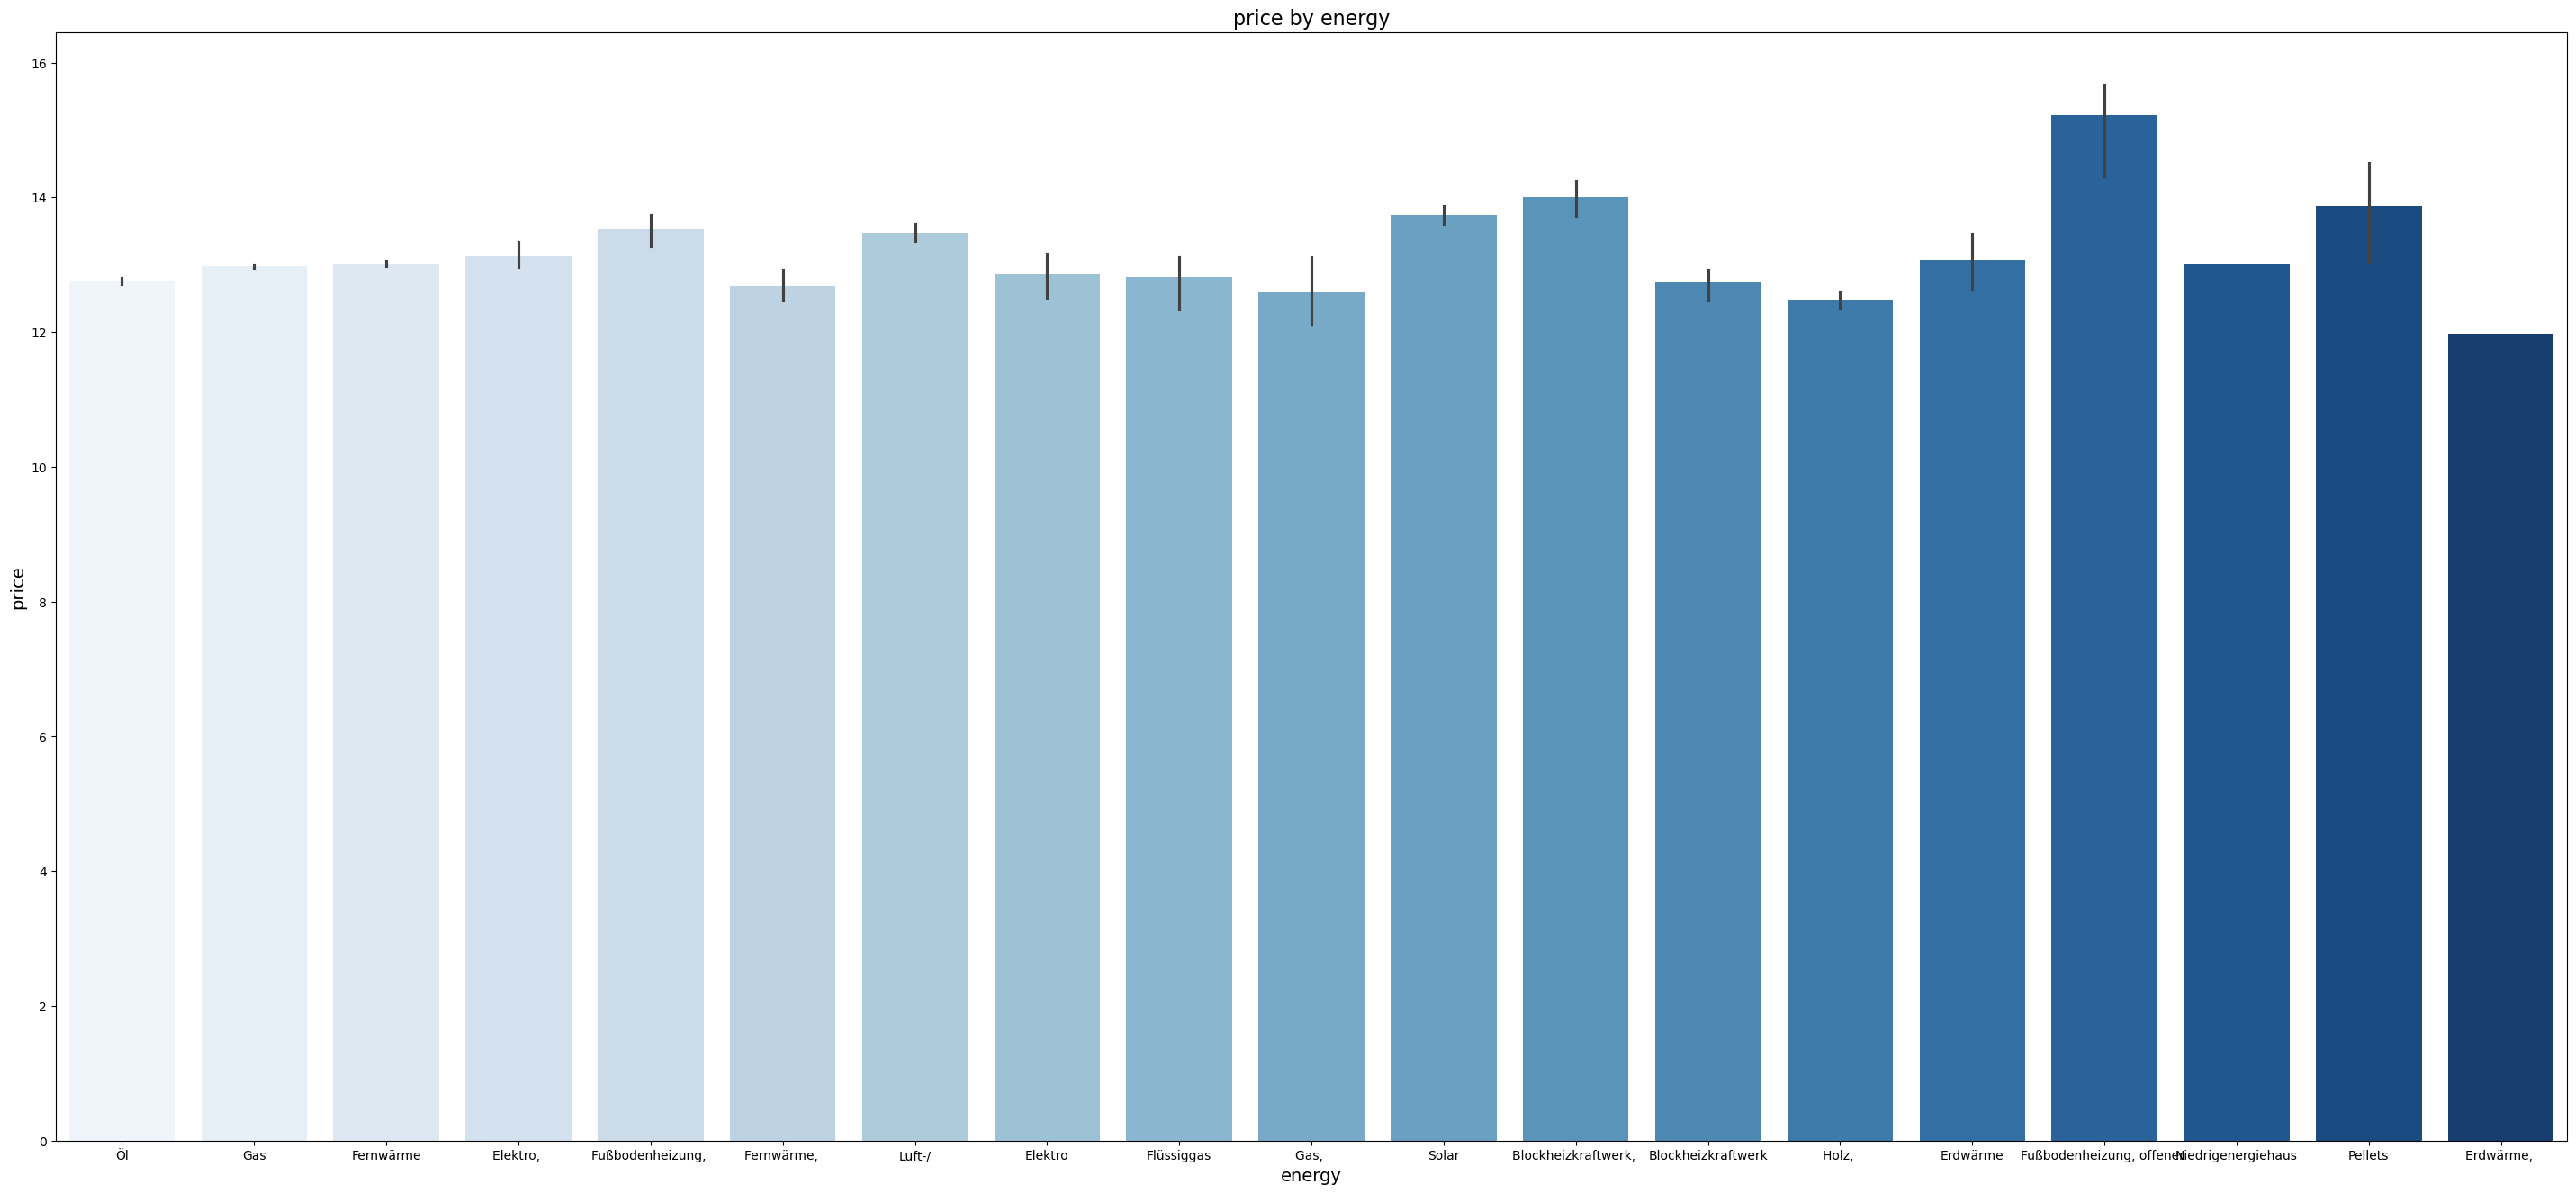

In [71]:
categorical_col = x.iloc[:, 1]  # First column (categorical)
numerical_col = y     # Second column (numerical)

# Create a new DataFrame combining both features for easier plotting
df_plot = pd.DataFrame({
    'categorical_feature': categorical_col,
    'numerical_feature': numerical_col
})

# Create a bar chart using seaborn
plt.figure(figsize=(36, 16))
sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')

# Add title and labels
plt.title('price by energy', fontsize=16)
plt.xlabel('energy', fontsize=14)
plt.ylabel('price', fontsize=14)

C:\Users\NOAVARAN\AppData\Local\Temp\ipykernel_6492\1618535898.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')


Text(0, 0.5, 'price')

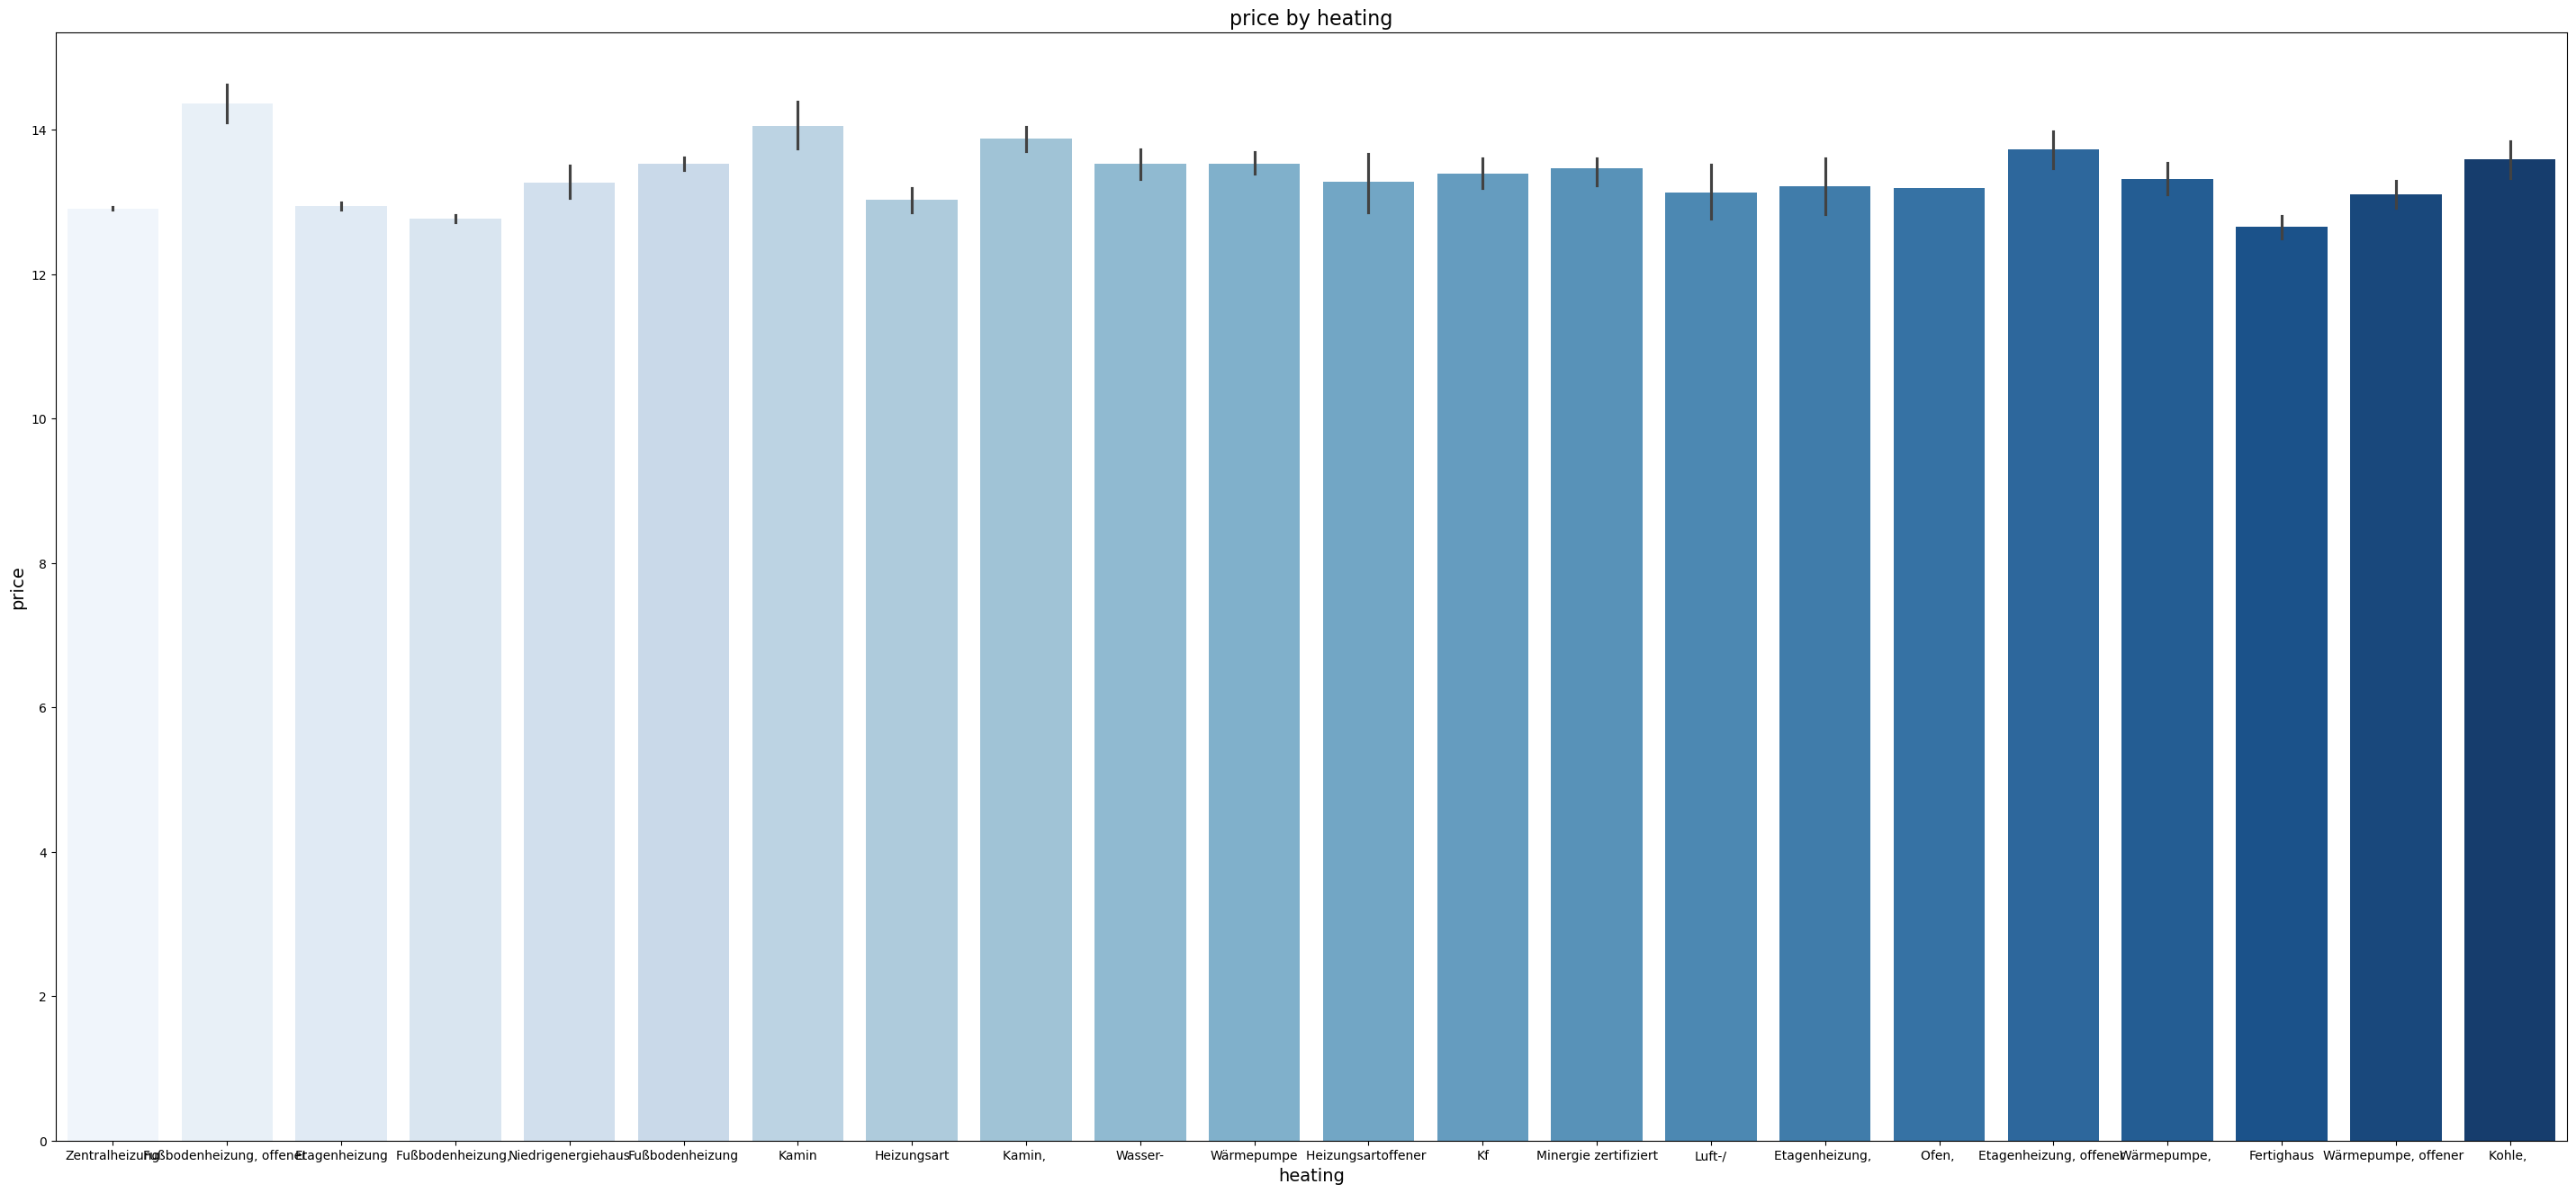

In [72]:
categorical_col = x.iloc[:, 2]  # First column (categorical)
numerical_col = y     # Second column (numerical)

# Create a new DataFrame combining both features for easier plotting
df_plot = pd.DataFrame({
    'categorical_feature': categorical_col,
    'numerical_feature': numerical_col
})

# Create a bar chart using seaborn
plt.figure(figsize=(36, 16))
sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')

# Add title and labels
plt.title('price by heating', fontsize=16)
plt.xlabel('heating', fontsize=14)
plt.ylabel('price', fontsize=14)

C:\Users\NOAVARAN\AppData\Local\Temp\ipykernel_6492\947155298.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')


Text(0, 0.5, 'price per area')

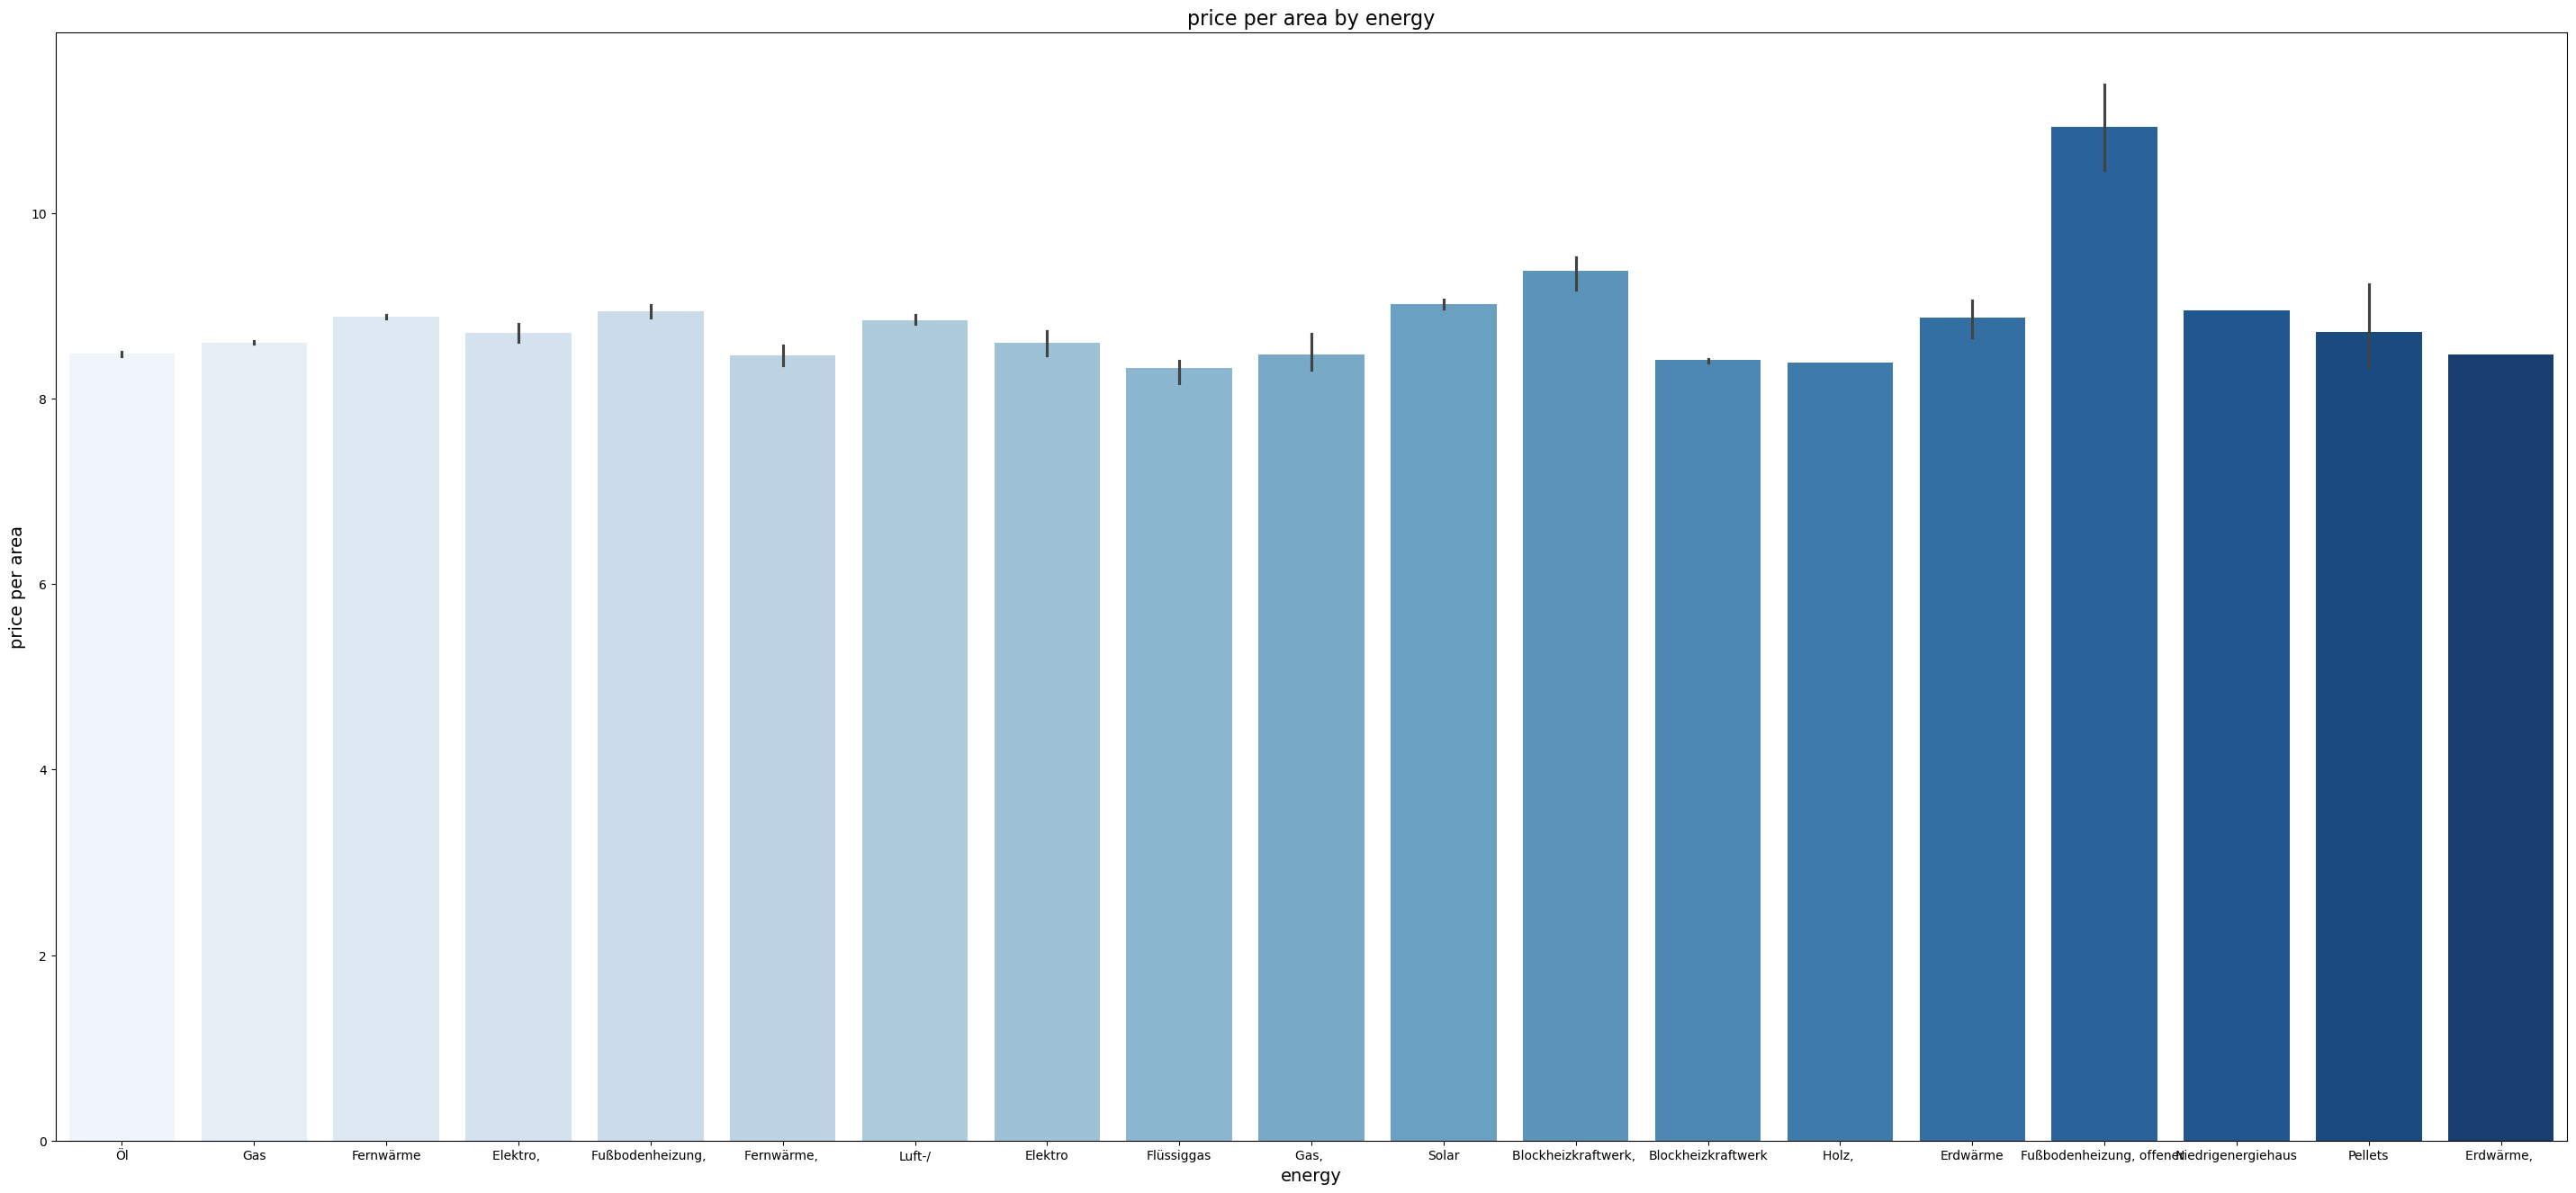

In [73]:
categorical_col = x.iloc[:, 1]  # First column (categorical)
numerical_col = x.iloc[:, -1]     # Last column (numerical)

# Create a new DataFrame combining both features for easier plotting
df_plot = pd.DataFrame({
    'categorical_feature': categorical_col,
    'numerical_feature': numerical_col
})

# Create a bar chart using seaborn
plt.figure(figsize=(36, 16))
sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')

# Add title and labels
plt.title('price per area by energy', fontsize=16)
plt.xlabel('energy', fontsize=14)
plt.ylabel('price per area', fontsize=14)

In [74]:
# outcome: Fußbodenheizung, offener is the most expensive, but does not have enough data(7)

C:\Users\NOAVARAN\AppData\Local\Temp\ipykernel_6492\158173371.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')


Text(0, 0.5, 'price per area')

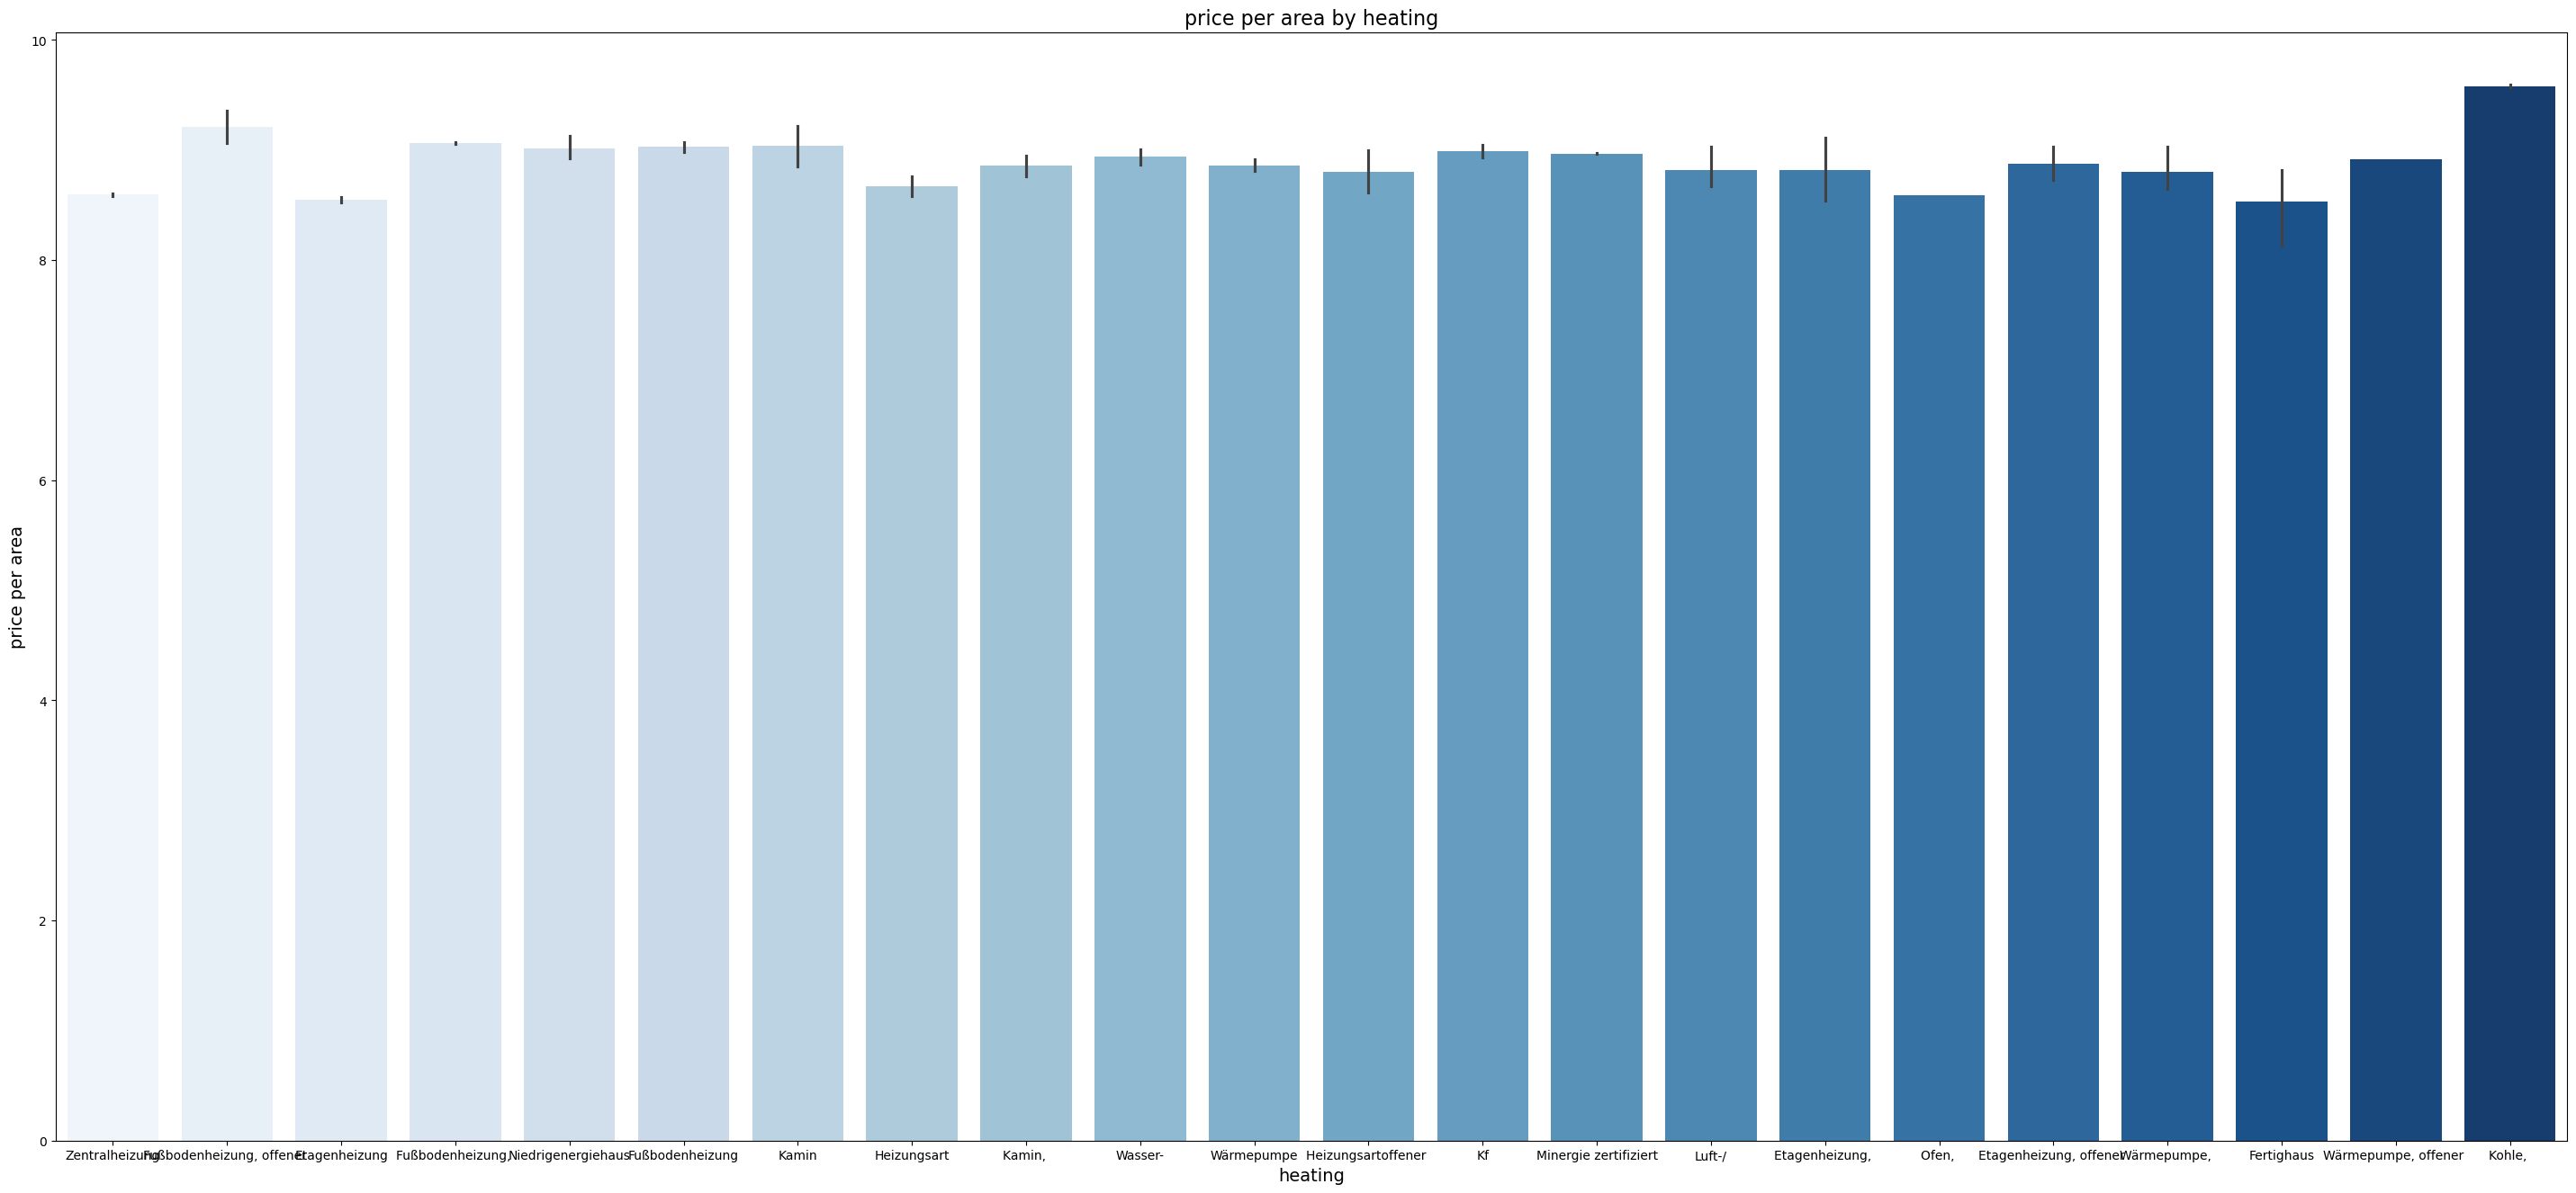

In [75]:
categorical_col = x.iloc[:, 2]  # First column (categorical)
numerical_col = x.iloc[:, -1]     # Last column (numerical)

# Create a new DataFrame combining both features for easier plotting
df_plot = pd.DataFrame({
    'categorical_feature': categorical_col,
    'numerical_feature': numerical_col
})

# Create a bar chart using seaborn
plt.figure(figsize=(36, 16))
sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')

# Add title and labels
plt.title('price per area by heating', fontsize=16)
plt.xlabel('heating', fontsize=14)
plt.ylabel('price per area', fontsize=14)

In [76]:
# outcome: Kohle is the most expensive, but does not have enough data(2)

## Mapping Energy and Heating Into 6 Gruops

In [77]:
x = data_cleaned.drop('price', axis=1).copy()

energy = x.iloc[:, 1].astype(str).str.strip()
heating = x.iloc[:, 2].astype(str).str.strip()

print("energy value_counts:")
print(energy.value_counts())
print("\nheating value_counts:")
print(heating.value_counts())

# ----- ENERGY -----
energy_top = {'Gas': 1, 'Fernwärme': 2, 'Öl': 3}
energy_mapped = energy.map(energy_top)

rest_mask = energy_mapped.isna()
rest_counts = energy[rest_mask].value_counts()
g4_labels = set(rest_counts[rest_counts >= 30].index)

energy_mapped.loc[rest_mask] = energy[rest_mask].apply(
    lambda v: 4 if v in g4_labels else 5
)

# ----- HEATING -----
heat_counts = heating.value_counts()
heat_ranked = list(heat_counts.index)

if 'Heizungsart' in heat_ranked:
    cut = heat_ranked.index('Heizungsart') + 1
else:
    cut = min(5, len(heat_ranked))

top_heat = heat_ranked[:cut]
heating_map = {label: i + 1 for i, label in enumerate(top_heat)}
heating_mapped = heating.map(heating_map).fillna(6)

energy_mapped = energy_mapped.astype(int)
heating_mapped = heating_mapped.astype(int)

# update x
x.iloc[:, 1] = energy_mapped
x.iloc[:, 2] = heating_mapped

# update data_cleaned so later cells keep working
data_cleaned = data_cleaned.copy()
data_cleaned['energy_encoded'] = energy_mapped.values
data_cleaned['heating_encoded'] = heating_mapped.values
data_cleaned['energy'] = energy_mapped.values
data_cleaned['heating'] = heating_mapped.values

print("\nenergy group labels for 4:", g4_labels)
print("heating labels 1-5:", heating_map)
print("\nfinal energy:")
print(data_cleaned['energy'].value_counts().sort_index())
print("\nfinal heating:")
print(data_cleaned['heating'].value_counts().sort_index())

energy value_counts:
energy
Gas                         2440
Fernwärme                   1605
Öl                           632
Fernwärme,                    49
Elektro,                      44
Luft-/                        44
Fußbodenheizung,              33
Elektro                       19
Blockheizkraftwerk,           16
Gas,                          16
Solar                         15
Erdwärme                       7
Flüssiggas                     6
Blockheizkraftwerk             5
Holz,                          3
Fußbodenheizung, offener       3
Pellets                        3
Niedrigenergiehaus             1
Erdwärme,                      1
Name: count, dtype: int64

heating value_counts:
heating
Zentralheizung              3171
Fußbodenheizung,             571
Etagenheizung                568
Fußbodenheizung              283
Heizungsart                  115
Kamin,                        38
Wärmepumpe                    37
Wasser-                       33
Kamin                   

In [78]:
x

,url,energy,heating,area,rooms,fee,zipcode,construction_year,level,price_per_area
0,https://www.immowelt.de/expose/29fhx5b,3,1,4.174387,0.869742,3.57,13505.0,1971.0,2.0,8.266582
1,https://www.immowelt.de/expose/29hzk5u,1,6,4.920419,0.959135,3.57,10405.0,1900.0,5.0,9.161030
2,https://www.immowelt.de/expose/292m95u,1,3,4.795791,0.959135,3.57,12161.0,1900.0,5.0,8.766810
3,https://www.immowelt.de/expose/29sh55u,1,1,5.068904,1.026672,3.57,12103.0,1956.0,1.0,7.700685
4,https://www.immowelt.de/expose/29r5y5t,1,3,4.844187,0.959135,3.57,12157.0,1909.0,3.0,8.276265
...,...,...,...,...,...,...,...,...,...,...
4937,https://www.immowelt.de/expose/2gd5v4m,1,1,4.369448,0.869742,3.57,13595.0,2000.0,1.0,8.612685
4938,https://www.immowelt.de/expose/2ga5t4m,1,1,5.017280,0.959135,3.57,13467.0,1990.0,1.0,8.488999
4939,https://www.immowelt.de/expose/2f79g4a,1,3,4.553877,0.869742,3.57,10115.0,1900.0,1.0,8.909370
4940,https://www.immowelt.de/expose/2ej2m4d,2,6,4.682131,0.869742,3.57,13591.0,1894.0,1.0,8.967564


C:\Users\NOAVARAN\AppData\Local\Temp\ipykernel_6492\3398794075.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')


Text(0, 0.5, 'price')

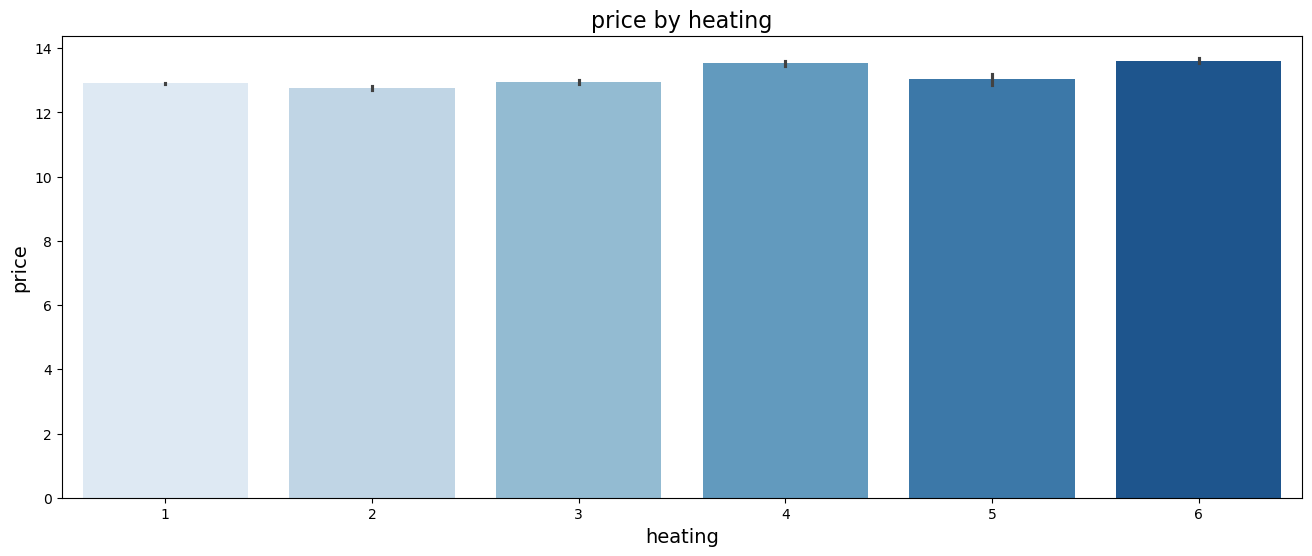

In [79]:
categorical_col = x.iloc[:, 2]  # First column (categorical)
numerical_col = y     # Second column (numerical)

# Create a new DataFrame combining both features for easier plotting
df_plot = pd.DataFrame({
    'categorical_feature': categorical_col,
    'numerical_feature': numerical_col
})

# Create a bar chart using seaborn
plt.figure(figsize=(16, 6))
sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')

# Add title and labels
plt.title('price by heating', fontsize=16)
plt.xlabel('heating', fontsize=14)
plt.ylabel('price', fontsize=14)

## Q. Plotting price per area by heating and energy

C:\Users\NOAVARAN\AppData\Local\Temp\ipykernel_6492\2369590736.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')


Text(0, 0.5, 'price')

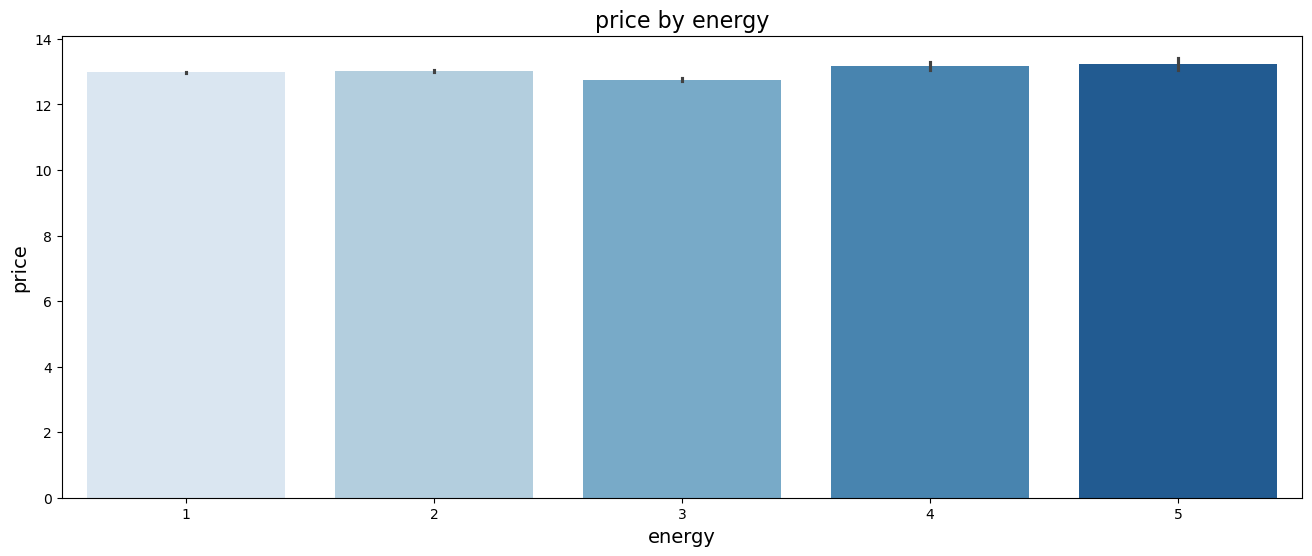

In [80]:
categorical_col = x.iloc[:, 1]  # First column (categorical)
numerical_col = y     # Second column (numerical)

# Create a new DataFrame combining both features for easier plotting
df_plot = pd.DataFrame({
    'categorical_feature': categorical_col,
    'numerical_feature': numerical_col
})

# Create a bar chart using seaborn
plt.figure(figsize=(16, 6))
sns.barplot(x='categorical_feature', y='numerical_feature', data=df_plot, estimator='mean', palette='Blues')

# Add title and labels
plt.title('price by energy', fontsize=16)
plt.xlabel('energy', fontsize=14)
plt.ylabel('price', fontsize=14)

In [81]:
# CC: Correlation Coefficient
Data = data_cleaned.drop(
    columns=[
        "url",
        "energy_encoded",
        "heating_encoded",
        "energy",
        "heating"
    ]
) 

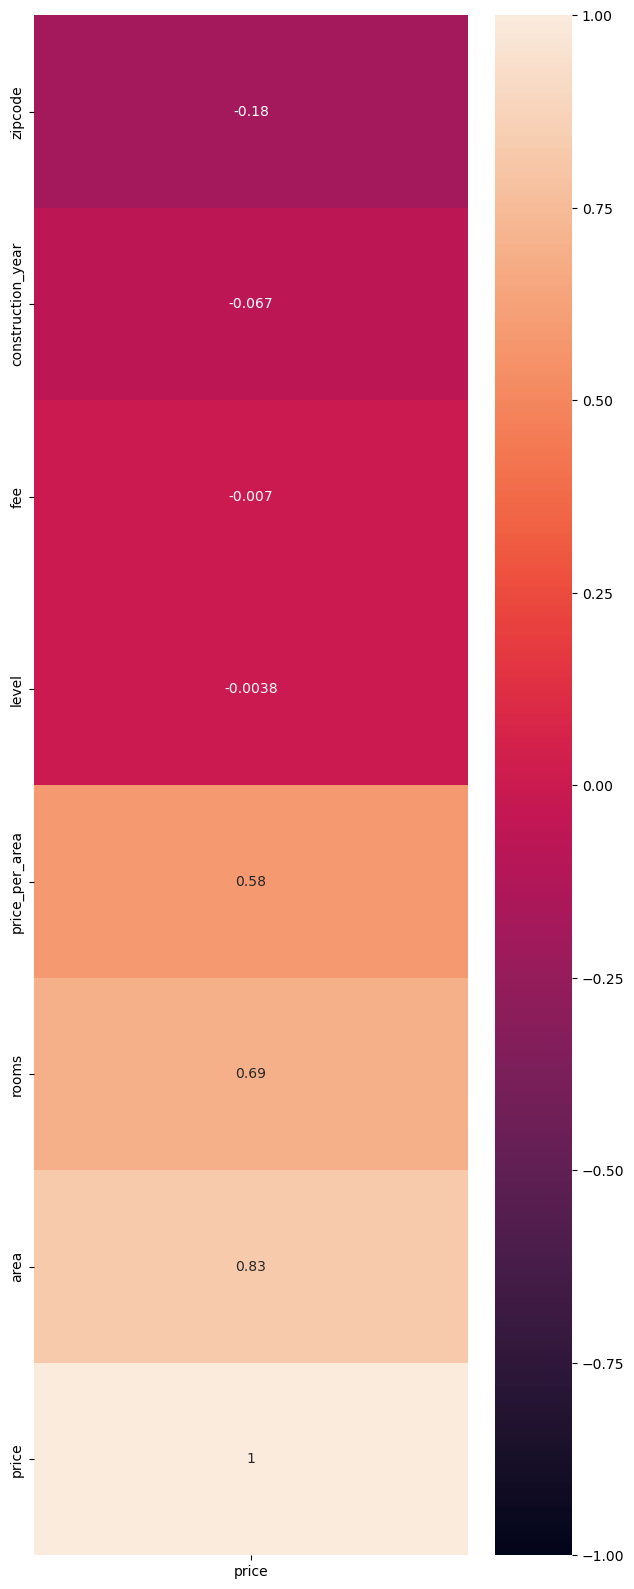

In [82]:
PriceCor = Data.corr()[["price"]].sort_values("price")
plt.figure(figsize=(7, 20))
sns.heatmap(
    PriceCor,
    vmin=-1,
    annot=True,
)
plt.show() 

In [83]:
data_cleaned

,url,energy,heating,price,area,rooms,fee,zipcode,construction_year,level,price_per_area,energy_encoded,heating_encoded
0,https://www.immowelt.de/expose/29fhx5b,3,1,12.425212,4.174387,0.869742,3.57,13505.0,1971.0,2.0,8.266582,3,1
1,https://www.immowelt.de/expose/29hzk5u,1,6,14.074022,4.920419,0.959135,3.57,10405.0,1900.0,5.0,9.161030,1,6
2,https://www.immowelt.de/expose/292m95u,1,3,13.554147,4.795791,0.959135,3.57,12161.0,1900.0,5.0,8.766810,1,3
3,https://www.immowelt.de/expose/29sh55u,1,1,12.762830,5.068904,1.026672,3.57,12103.0,1956.0,1.0,7.700685,1,1
4,https://www.immowelt.de/expose/29r5y5t,1,3,13.112295,4.844187,0.959135,3.57,12157.0,1909.0,3.0,8.276265,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4937,https://www.immowelt.de/expose/2gd5v4m,1,1,12.969215,4.369448,0.869742,3.57,13595.0,2000.0,1.0,8.612685,1,1
4938,https://www.immowelt.de/expose/2ga5t4m,1,1,13.499430,5.017280,0.959135,3.57,13467.0,1990.0,1.0,8.488999,1,1
4939,https://www.immowelt.de/expose/2f79g4a,1,3,13.452531,4.553877,0.869742,3.57,10115.0,1900.0,1.0,8.909370,1,3
4940,https://www.immowelt.de/expose/2ej2m4d,2,6,13.640266,4.682131,0.869742,3.57,13591.0,1894.0,1.0,8.967564,2,6


In [84]:
x

,url,energy,heating,area,rooms,fee,zipcode,construction_year,level,price_per_area
0,https://www.immowelt.de/expose/29fhx5b,3,1,4.174387,0.869742,3.57,13505.0,1971.0,2.0,8.266582
1,https://www.immowelt.de/expose/29hzk5u,1,6,4.920419,0.959135,3.57,10405.0,1900.0,5.0,9.161030
2,https://www.immowelt.de/expose/292m95u,1,3,4.795791,0.959135,3.57,12161.0,1900.0,5.0,8.766810
3,https://www.immowelt.de/expose/29sh55u,1,1,5.068904,1.026672,3.57,12103.0,1956.0,1.0,7.700685
4,https://www.immowelt.de/expose/29r5y5t,1,3,4.844187,0.959135,3.57,12157.0,1909.0,3.0,8.276265
...,...,...,...,...,...,...,...,...,...,...
4937,https://www.immowelt.de/expose/2gd5v4m,1,1,4.369448,0.869742,3.57,13595.0,2000.0,1.0,8.612685
4938,https://www.immowelt.de/expose/2ga5t4m,1,1,5.017280,0.959135,3.57,13467.0,1990.0,1.0,8.488999
4939,https://www.immowelt.de/expose/2f79g4a,1,3,4.553877,0.869742,3.57,10115.0,1900.0,1.0,8.909370
4940,https://www.immowelt.de/expose/2ej2m4d,2,6,4.682131,0.869742,3.57,13591.0,1894.0,1.0,8.967564


In [85]:
x = x.iloc[:, [1,2,3,4]]
x

,energy,heating,area,rooms
0,3,1,4.174387,0.869742
1,1,6,4.920419,0.959135
2,1,3,4.795791,0.959135
3,1,1,5.068904,1.026672
4,1,3,4.844187,0.959135
...,...,...,...,...
4937,1,1,4.369448,0.869742
4938,1,1,5.017280,0.959135
4939,1,3,4.553877,0.869742
4940,2,6,4.682131,0.869742


In [86]:
y=data_cleaned['price']
y

0       12.425212
1       14.074022
2       13.554147
3       12.762830
4       13.112295
          ...    
4937    12.969215
4938    13.499430
4939    13.452531
4940    13.640266
4941    12.301387
Name: price, Length: 4942, dtype: float64

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0, 1])], remainder='passthrough')
X = np.array(ct.fit_transform(x))

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [89]:
print(X_train)

[[0.         1.         0.         ... 0.         3.13549422 0.52658903]
 [1.         0.         0.         ... 0.         4.70862889 0.86974169]
 [1.         0.         0.         ... 0.         3.67325807 0.52658903]
 ...
 [1.         0.         0.         ... 0.         4.98360662 1.02667203]
 [1.         0.         0.         ... 0.         4.73619845 0.86974169]
 [1.         0.         0.         ... 0.         4.18661984 0.74127631]]


In [90]:
print(X_test)

[[1.         0.         0.         ... 0.         4.32439752 0.86974169]
 [0.         1.         0.         ... 0.         3.66356165 0.52658903]
 [1.         0.         0.         ... 0.         4.16852396 0.74127631]
 ...
 [0.         0.         1.         ... 0.         3.93182563 0.74127631]
 [0.         1.         0.         ... 0.         5.40717177 0.95913484]
 [1.         0.         0.         ... 1.         4.11251187 0.74127631]]


In [91]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:, :] = sc.fit_transform(X_train[:, :])
X_test[:, :] = sc.transform(X_test[:, :])

In [92]:
# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
)
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV

In [93]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [94]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=1),
    "Random Forest Regressor": RandomForestRegressor(random_state=1, n_jobs=-1),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=1),
    "GradientBoosting": GradientBoostingRegressor(random_state=1),
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('=' * 35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.3231
- Mean Absolute Error: 0.2408
- R2 Score: 0.7727
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3251
- Mean Absolute Error: 0.2463
- R2 Score: 0.7681


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.6776
- Mean Absolute Error: 0.5410
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.6766
- Mean Absolute Error: 0.5367
- R2 Score: -0.0046


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.3231
- Mean Absolute Error: 0.2408
- R2 Score: 0.7727
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3251
- Mean Absolute Error: 0.2463
- R2 Score: 0.7681


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2633
- Mean Absolute Error: 0.1876
- R2 Score: 0.8490
----------------------

In [95]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5, 1.0],
}

rf = RandomForestRegressor(random_state=1, n_jobs=-1)
search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R2:", search.best_score_)

y_train_pred = search.predict(X_train)
y_test_pred = search.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

print("\nTuned Random Forest")
print("Train  RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(train_rmse, train_mae, train_r2))
print("Test   RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(test_rmse, test_mae, test_r2))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10}
Best CV R2: 0.7956582138182169

Tuned Random Forest
Train  RMSE: 0.2579 | MAE: 0.1933 | R2: 0.8551
Test   RMSE: 0.3007 | MAE: 0.2204 | R2: 0.8016


In [96]:
param_dist_hgb = {
    'learning_rate': [0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, None],
    'max_iter': [100, 200, 300, 500],
    'min_samples_leaf': [5, 10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0],
}

hgb = HistGradientBoostingRegressor(random_state=1)
search_hgb = RandomizedSearchCV(
    hgb,
    param_distributions=param_dist_hgb,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
    verbose=1,
)

search_hgb.fit(X_train, y_train)

print("Best params (HGB):", search_hgb.best_params_)
print("Best CV R2:", search_hgb.best_score_)

y_train_pred = search_hgb.predict(X_train)
y_test_pred = search_hgb.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

print("\nTuned HistGradientBoosting")
print("Train  RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(train_rmse, train_mae, train_r2))
print("Test   RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(test_rmse, test_mae, test_r2))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (HGB): {'min_samples_leaf': 5, 'max_iter': 200, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 0.1}
Best CV R2: 0.7952953167389717

Tuned HistGradientBoosting
Train  RMSE: 0.2605 | MAE: 0.1967 | R2: 0.8522
Test   RMSE: 0.3062 | MAE: 0.2239 | R2: 0.7943


In [97]:
param_dist_gb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.85, 1.0],
}

gb = GradientBoostingRegressor(random_state=1)
search_gb = RandomizedSearchCV(
    gb,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=1,
    n_jobs=-1,
    verbose=1,
)

search_gb.fit(X_train, y_train)

print("Best params (GB):", search_gb.best_params_)
print("Best CV R2:", search_gb.best_score_)

y_train_pred = search_gb.predict(X_train)
y_test_pred = search_gb.predict(X_test)

train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

print("\nTuned GradientBoosting")
print("Train  RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(train_rmse, train_mae, train_r2))
print("Test   RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(test_rmse, test_mae, test_r2))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (GB): {'subsample': 0.85, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.1}
Best CV R2: 0.799178964102084

Tuned GradientBoosting
Train  RMSE: 0.2689 | MAE: 0.2053 | R2: 0.8426
Test   RMSE: 0.3050 | MAE: 0.2248 | R2: 0.7958
